c:\Users\maycha\Desktop\text\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU Name: NVIDIA GeForce RTX 3050 Laptop GPU

Generating Data Exploration (EDA) Plots...


C:\Users\maycha\AppData\Local\Temp\ipykernel_1728\919512289.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.values, y=[target_names[i] for i in class_counts.index], palette="viridis")


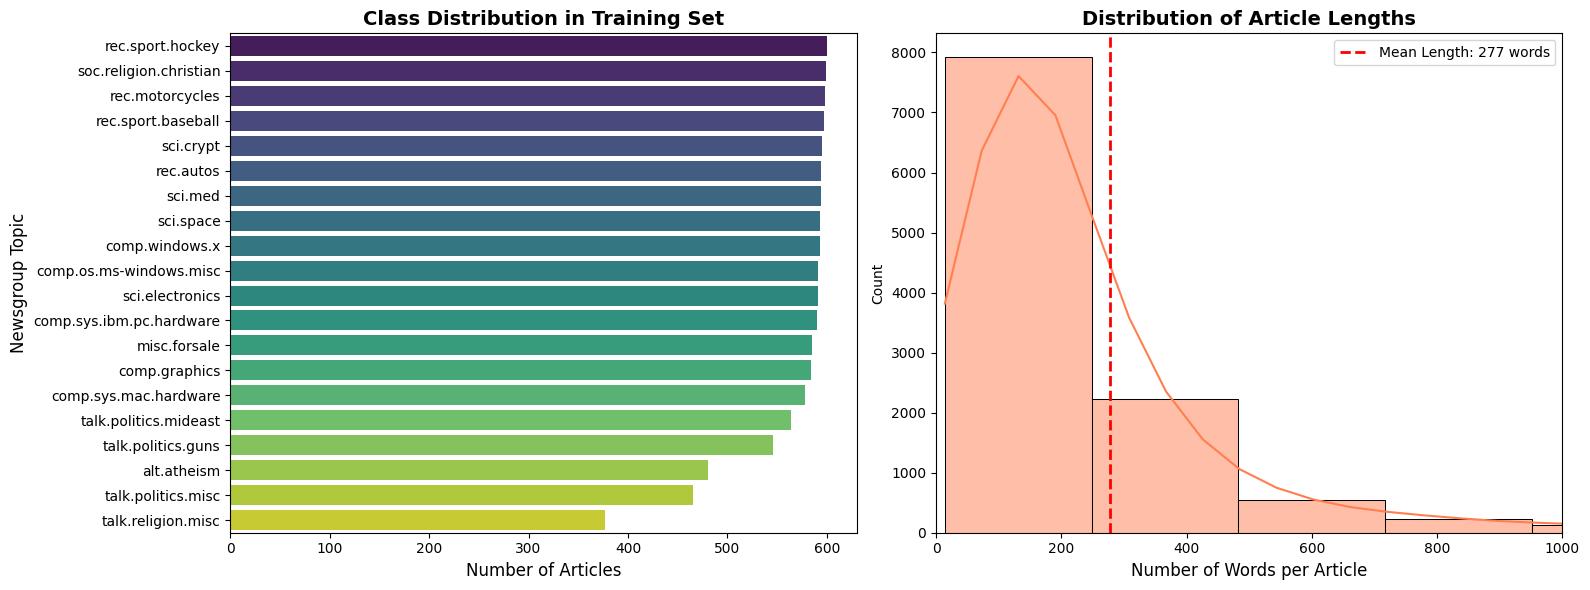

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from preprocess_text import load_and_clean_data, get_rnn_dataloaders
from ulti_text import train_and_eval

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available(): print(f"GPU Name: {torch.cuda.get_device_name(0)}")

df_train, df_test, target_names = load_and_clean_data()
train_loader, test_loader, vocab = get_rnn_dataloaders(df_train, df_test, batch_size=32)

print("\nGenerating Data Exploration (EDA) Plots...")
train_lengths = [len(str(text).split()) for text in df_train['text']]
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
class_counts = df_train['label'].value_counts()
sns.barplot(x=class_counts.values, y=[target_names[i] for i in class_counts.index], palette="viridis")
plt.title("Class Distribution in Training Set", fontsize=14, fontweight='bold')
plt.xlabel("Number of Articles", fontsize=12)
plt.ylabel("Newsgroup Topic", fontsize=12)

plt.subplot(1, 2, 2)
sns.histplot(train_lengths, bins=50, color='coral', kde=True)
mean_length = np.mean(train_lengths)
plt.axvline(mean_length, color='red', linestyle='dashed', linewidth=2, label=f'Mean Length: {mean_length:.0f} words')
plt.title("Distribution of Article Lengths", fontsize=14, fontweight='bold')
plt.xlabel("Number of Words per Article", fontsize=12)
plt.xlim(0, 1000)
plt.legend()
plt.tight_layout()
plt.show()

In [2]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super(RNNClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
        
    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        hidden_concat = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        return self.fc(hidden_concat)

model_rnn = RNNClassifier(len(vocab), 128, 128, 20).to(device)
print("RNN Model initialized.")

RNN Model initialized.



STARTING TRAINING: RNN


Epoch 1/5 [Eval]: 100%|██████████| 236/236 [00:05<00:00, 43.19it/s]



Result Epoch 1: Train Loss: 2.4278 | Accuracy: 0.3459 | F1-Score: 0.3570



Epoch 2/5 [Eval]: 100%|██████████| 236/236 [00:01<00:00, 162.20it/s]



Result Epoch 2: Train Loss: 1.2577 | Accuracy: 0.5094 | F1-Score: 0.5119



...


Result Epoch 3: Train Loss: 0.6424 | Accuracy: 0.5591 | F1-Score: 0.5697



Epoch 4/5 [Eval]: 100%|██████████| 236/236 [00:04<00:00, 52.64it/s]



Result Epoch 4: Train Loss: 0.3242 | Accuracy: 0.5929 | F1-Score: 0.5950



Epoch 5/5 [Eval]: 100%|██████████| 236/236 [00:05<00:00, 44.28it/s]



Result Epoch 5: Train Loss: 0.1982 | Accuracy: 0.5965 | F1-Score: 0.6019



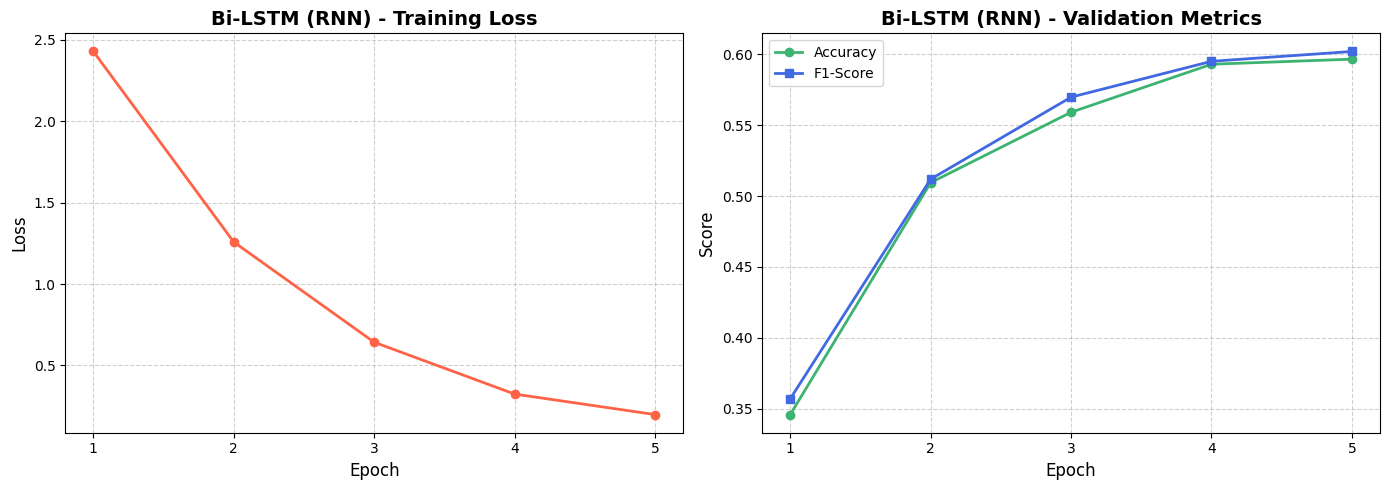

In [ ]:
import matplotlib.pyplot as plt

def plot_learning_curves(history, title):
    epochs_range = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], 'o-', color='tomato', linewidth=2)
    plt.title(f'{title} - Training Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.xticks(epochs_range)
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['val_acc'], 'o-', color='mediumseagreen', label='Accuracy', linewidth=2)
    plt.plot(epochs_range, history['val_f1'], 's-', color='royalblue', label='F1-Score', linewidth=2)
    plt.title(f'{title} - Validation Metrics', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.xticks(epochs_range)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model_rnn.parameters(), lr=1e-3)

history_rnn = train_and_eval(
    model_rnn, train_loader, test_loader, optimizer, criterion, device, 
    epochs=5, model_type="RNN"
)

plot_learning_curves(history_rnn, "Bi-LSTM (RNN)")

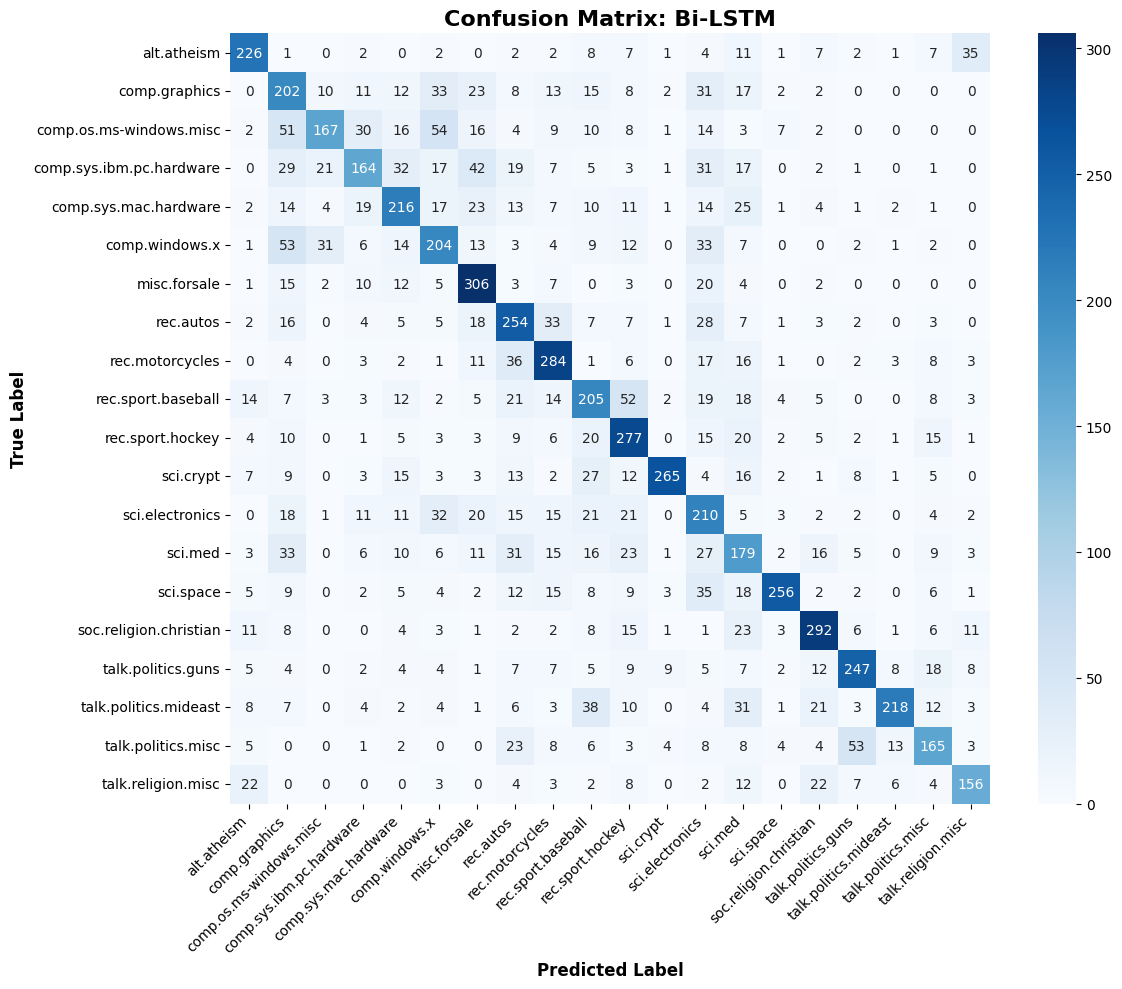

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model, test_loader, device, target_names, title, model_type="RNN"):
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch in test_loader:
            inputs, labels = batch
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Confusion Matrix: {title}', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(model_rnn, test_loader, device, target_names, "Bi-LSTM")